# LSTM Baseline
Baseline DL theo pipeline TLSTM, so sanh voi metric: Accuracy, Macro F1, AUC, QWK.

In [1]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc, cohen_kappa_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def detect_kaggle_runtime() -> bool:
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()

IN_KAGGLE = detect_kaggle_runtime()

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start

PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / 'credit_rating_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', device)
print('Project root:', PROJECT_ROOT)

Device: cpu
Project root: /kaggle/working


In [2]:
FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio', 'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin', 'net_profit_margin', 'asset_turnover',
    'roe', 'roa', 'operating_cashflow_ps', 'free_cashflow_ps'
]
TARGET_COL = 'rating_detail'
TARGET_ORDERED_LABELS = ['Distressed', 'HY', 'IG']
INPUT_SIZE = 1
HORIZON = 1

def resolve_split_path(default_path, local_fallbacks=None):
    candidates = [Path(default_path)]
    for p in (local_fallbacks or []):
        p_obj = Path(p)
        candidates.append(PROJECT_ROOT / p_obj if not p_obj.is_absolute() else p_obj)
    if IN_KAGGLE:
        kaggle_root = Path('/kaggle/input')
        expanded = []
        for p in candidates:
            expanded.append(p)
            if not p.exists() and kaggle_root.exists():
                expanded.extend(kaggle_root.rglob(p.name))
        candidates = expanded
    seen = set()
    deduped = []
    for p in candidates:
        p = Path(p)
        key = str(p)
        if key not in seen:
            seen.add(key)
            deduped.append(p)
    for p in deduped:
        if p.exists():
            return p
    raise FileNotFoundError(f'Khong tim thay file split: {deduped}')

TRAIN_PATH = resolve_split_path('/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv', ['data/processed/train_augmented_timegan.csv'])
VAL_PATH = resolve_split_path('/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv', ['data/processed/val.csv'])
TEST_PATH = resolve_split_path('/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv', ['data/processed/test.csv'])

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)
train_df['__split__'] = 'train'
val_df['__split__'] = 'val'
test_df['__split__'] = 'test'
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

df = df.dropna(subset=[TARGET_COL]).copy()
target_as_num = pd.to_numeric(df[TARGET_COL], errors='coerce')
if target_as_num.notna().all():
    df[TARGET_COL] = target_as_num.astype(int)
    observed = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(v): i for i, v in enumerate(observed)}
    id_to_raw = {i: int(v) for v, i in raw_to_id.items()}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    tgt = df[TARGET_COL].astype(str).str.strip()
    observed = sorted(tgt.unique().tolist())
    ordered = [x for x in TARGET_ORDERED_LABELS if x in observed] if set(observed).issubset(set(TARGET_ORDERED_LABELS)) else observed
    raw_to_id = {v: i for i, v in enumerate(ordered)}
    id_to_raw = {i: v for v, i in raw_to_id.items()}
    df[TARGET_COL] = tgt.map(raw_to_id).astype(int)

n_classes = int(df[TARGET_COL].nunique())
df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce', format='mixed')
if 'sector' not in df.columns:
    df['sector'] = 'UNKNOWN'
df['sector'] = df['sector'].fillna('UNKNOWN').astype(str)
sector_encoder = LabelEncoder()
df['sector_id'] = sector_encoder.fit_transform(df['sector'])
n_sectors = int(df['sector_id'].nunique())

train_mask = df['__split__'].eq('train')
stats_ref = df.loc[train_mask].copy() if train_mask.any() else df.copy()
for c in FINANCIAL_FEATURES:
    med = stats_ref[c].median() if stats_ref[c].notna().any() else 0.0
    df[c] = df[c].fillna(float(0.0 if pd.isna(med) else med))
for c in FINANCIAL_FEATURES:
    lo = stats_ref[c].quantile(0.01)
    hi = stats_ref[c].quantile(0.99)
    if pd.notna(lo) and pd.notna(hi):
        df[c] = df[c].clip(float(lo), float(hi))

df = df.sort_values(['ticker', 'rating_date']).reset_index(drop=True)
for c in FINANCIAL_FEATURES:
    df[f'{c}_delta'] = df.groupby('ticker')[c].diff().fillna(0.0)
MODEL_FEATURES = FINANCIAL_FEATURES + [f'{c}_delta' for c in FINANCIAL_FEATURES]

scaler = RobustScaler()
scaler.fit(df.loc[df['__split__'].eq('train'), MODEL_FEATURES].values)
df[MODEL_FEATURES] = scaler.transform(df[MODEL_FEATURES].values)

def build_padded_window(values, target_idx, input_size):
    if target_idx <= 0:
        x_raw = values[:1]
    else:
        x_raw = values[max(0, target_idx - input_size):target_idx]
    if x_raw.shape[0] == 0:
        x_raw = values[:1]
    if x_raw.shape[0] >= input_size:
        return x_raw[-input_size:]
    pad = np.repeat(x_raw[[0]], input_size - x_raw.shape[0], axis=0)
    return np.concatenate([pad, x_raw], axis=0)

def build_sequences(frame, input_size=8, horizon=1):
    out = {'train': [], 'val': [], 'test': []}
    for _, g in frame.groupby('ticker'):
        g = g.sort_values('rating_date').reset_index(drop=True)
        vals = g[MODEL_FEATURES].values.astype(np.float32)
        ys = g[TARGET_COL].values.astype(int)
        sec = g['sector_id'].values.astype(int)
        sp = g['__split__'].astype(str).str.lower().values
        n = len(g)
        if n >= input_size + horizon:
            for i in range(n - input_size - horizon + 1):
                t = i + input_size
                out[sp[t]].append((vals[i:i+input_size], int(ys[i+input_size-1]), int(sec[t]), int(ys[t])))
        else:
            t = n - 1
            x = build_padded_window(vals, t, input_size)
            out[sp[t]].append((x, int(ys[max(0, t-1)]), int(sec[t]), int(ys[t])))
    return out

seqs = build_sequences(df, input_size=INPUT_SIZE, horizon=HORIZON)
for split_name in ['train', 'val', 'test']:
    if len(seqs[split_name]) == 0:
        raise ValueError(f'Split {split_name} khong co mau sau khi tao window; kiem tra lai du lieu va INPUT_SIZE.')

class WindowDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        x, ly, sec, y = self.samples[i]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(ly, dtype=torch.long),
            torch.tensor(sec, dtype=torch.long),
            torch.tensor(y, dtype=torch.long),
        )

train_ds = WindowDataset(seqs['train'])
val_ds = WindowDataset(seqs['val'])
test_ds = WindowDataset(seqs['test'])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)

print('Train/Val/Test windows:', len(train_ds), len(val_ds), len(test_ds))
print('n_classes:', n_classes, '| n_sectors:', n_sectors, '| n_features:', len(MODEL_FEATURES))

Train/Val/Test windows: 7109 2202 1155
n_classes: 3 | n_sectors: 12 | n_features: 24


In [3]:
def compute_metrics(y_true, y_pred, proba, n_cls):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    try:
        y_bin = label_binarize(y_true, classes=list(range(n_cls)))
        auc = roc_auc_score(y_bin, proba, average='macro', multi_class='ovr')
    except Exception:
        auc = float('nan')
    return {
        'Accuracy': float(acc),
        'Precision_Weighted': float(prec),
        'Recall_Weighted': float(rec),
        'Macro_F1': float(f1m),
        'Weighted_F1': float(f1w),
        'AUC': float(auc),
        'QWK': float(qwk)
    }

class LSTMClassifier(nn.Module):
    def __init__(self, n_features, n_classes, n_sectors, hidden=128, layers=2, drop=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=layers,
            dropout=drop if layers > 1 else 0.0,
            bidirectional=True,
            batch_first=True,
        )
        self.last_y_emb = nn.Embedding(n_classes, 16)
        self.sector_emb = nn.Embedding(n_sectors, 8)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2 + 16 + 8, hidden),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x, last_y, sector_id):
        out, _ = self.lstm(x)
        feat = out[:, -1, :]
        ly = self.last_y_emb(last_y)
        sec = self.sector_emb(sector_id)
        return self.head(torch.cat([feat, ly, sec], dim=1))

def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss = 0.0
    all_y, all_pred, all_prob = [], [], []

    for xb, lyb, sb, yb in loader:
        xb, lyb, sb, yb = xb.to(device), lyb.to(device), sb.to(device), yb.to(device)
        with torch.set_grad_enabled(train_mode):
            logits = model(xb, lyb, sb)
            loss = criterion(logits, yb)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        prob = torch.softmax(logits, dim=1).detach().cpu().numpy()
        pred = np.argmax(prob, axis=1)
        all_prob.append(prob)
        all_pred.append(pred)
        all_y.append(yb.detach().cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    y_prob = np.concatenate(all_prob)
    metrics = compute_metrics(y_true, y_pred, y_prob, n_classes)
    metrics['Loss'] = total_loss / max(1, len(loader.dataset))
    return metrics

In [4]:
class FocalOrdinalLoss(nn.Module):
    """Focal + ordinal regularization for ordered rating classes."""
    def __init__(self, n_classes, gamma=1.5, ordinal_alpha=0.04, label_smoothing=0.0):
        super().__init__()
        self.n_classes = int(n_classes)
        self.gamma = float(gamma)
        self.ordinal_alpha = float(ordinal_alpha)
        self.label_smoothing = float(label_smoothing)

    def forward(self, logits, targets):
        logits = logits.float()
        log_probs = torch.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)

        if self.label_smoothing > 0.0 and self.n_classes > 1:
            smooth = self.label_smoothing
            smooth_targets = torch.full_like(
                log_probs,
                fill_value=smooth / max(1, self.n_classes - 1),
            )
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - smooth)
            pt = (probs * smooth_targets).sum(dim=1).clamp(min=1e-8, max=1.0 - 1e-8)
        else:
            pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8, max=1.0 - 1e-8)

        focal_term = (-((1.0 - pt) ** self.gamma) * torch.log(pt)).mean()

        if self.ordinal_alpha <= 0.0:
            return focal_term

        class_positions = torch.arange(self.n_classes, device=logits.device, dtype=probs.dtype)
        expected_rank = (probs * class_positions.unsqueeze(0)).sum(dim=1)
        target_rank = targets.to(dtype=probs.dtype)
        denom = max(1.0, float(self.n_classes - 1))
        ordinal_term = ((expected_rank - target_rank) / denom).pow(2).mean()

        return focal_term + self.ordinal_alpha * ordinal_term


model = LSTMClassifier(
    n_features=len(MODEL_FEATURES),
    n_classes=n_classes,
    n_sectors=n_sectors,
    hidden=128,
    layers=2,
    drop=0.2,
).to(device)

criterion_settings = {
    'focal_gamma': 1.5,
    'ordinal_alpha': 0.04,
    'label_smoothing': 0.0,
}
criterion = FocalOrdinalLoss(
    n_classes=n_classes,
    gamma=criterion_settings['focal_gamma'],
    ordinal_alpha=criterion_settings['ordinal_alpha'],
    label_smoothing=criterion_settings['label_smoothing'],
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
print(
    f"Loss: focal_ordinal | gamma={criterion_settings['focal_gamma']} | "
    f"ordinal_alpha={criterion_settings['ordinal_alpha']} | "
    f"label_smoothing={criterion_settings['label_smoothing']}"
 )

history = {
    'epoch': [],
    'train_Loss': [], 'val_Loss': [],
    'train_Accuracy': [], 'val_Accuracy': [],
    'train_Macro_F1': [], 'val_Macro_F1': [],
    'train_AUC': [], 'val_AUC': [],
    'train_QWK': [], 'val_QWK': [],
}

best_val_f1 = -1.0
best_state = None
patience, no_improve = 10, 0
max_epochs = 50

for epoch in range(1, max_epochs + 1):
    tr = run_epoch(model, train_loader, criterion, optimizer)
    va = run_epoch(model, val_loader, criterion, optimizer=None)

    history['epoch'].append(epoch)
    history['train_Loss'].append(float(tr['Loss']))
    history['val_Loss'].append(float(va['Loss']))
    for metric_name in ['Accuracy', 'Macro_F1', 'AUC', 'QWK']:
        history[f'train_{metric_name}'].append(float(tr[metric_name]))
        history[f'val_{metric_name}'].append(float(va[metric_name]))

    print(
        f"Epoch {epoch:02d} | TrLoss {tr['Loss']:.4f} | VaLoss {va['Loss']:.4f} | "
        f"VaAcc {va['Accuracy']:.4f} | VaF1 {va['Macro_F1']:.4f} | VaAUC {va['AUC']:.4f} | VaQWK {va['QWK']:.4f}"
    )

    if va['Macro_F1'] > best_val_f1 + 1e-4:
        best_val_f1 = va['Macro_F1']
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print('Early stopping.')
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_path = ARTIFACT_DIR / 'lstm_training_history.csv'
history_df.to_csv(history_path, index=False)

val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)
test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)

report = pd.DataFrame([
    {'Split': 'Val', **{k: v for k, v in val_metrics.items() if k in ['Accuracy', 'Macro_F1', 'AUC', 'QWK']}},
    {'Split': 'Test', **{k: v for k, v in test_metrics.items() if k in ['Accuracy', 'Macro_F1', 'AUC', 'QWK']}},
])
display(report)

out_path = ARTIFACT_DIR / 'lstm_metrics.csv'
report.to_csv(out_path, index=False)
print('Saved:', out_path)
print('Saved:', history_path)

Loss: focal_ordinal | gamma=1.5 | ordinal_alpha=0.04 | label_smoothing=0.0
Epoch 01 | TrLoss 0.2542 | VaLoss 0.1451 | VaAcc 0.9173 | VaF1 0.8041 | VaAUC 0.9200 | VaQWK 0.8388
Epoch 02 | TrLoss 0.0943 | VaLoss 0.1399 | VaAcc 0.9173 | VaF1 0.8041 | VaAUC 0.9228 | VaQWK 0.8388
Epoch 03 | TrLoss 0.0857 | VaLoss 0.1372 | VaAcc 0.9169 | VaF1 0.7994 | VaAUC 0.9246 | VaQWK 0.8376
Epoch 04 | TrLoss 0.0798 | VaLoss 0.1379 | VaAcc 0.9173 | VaF1 0.8016 | VaAUC 0.9268 | VaQWK 0.8381
Epoch 05 | TrLoss 0.0760 | VaLoss 0.1400 | VaAcc 0.9160 | VaF1 0.7916 | VaAUC 0.9253 | VaQWK 0.8349
Epoch 06 | TrLoss 0.0740 | VaLoss 0.1376 | VaAcc 0.9169 | VaF1 0.8012 | VaAUC 0.9275 | VaQWK 0.8373
Epoch 07 | TrLoss 0.0700 | VaLoss 0.1397 | VaAcc 0.9137 | VaF1 0.7948 | VaAUC 0.9284 | VaQWK 0.8317
Epoch 08 | TrLoss 0.0669 | VaLoss 0.1411 | VaAcc 0.9124 | VaF1 0.7729 | VaAUC 0.9277 | VaQWK 0.8273
Epoch 09 | TrLoss 0.0658 | VaLoss 0.1424 | VaAcc 0.9087 | VaF1 0.7569 | VaAUC 0.9268 | VaQWK 0.8193
Epoch 10 | TrLoss 0.0647 

,Split,Accuracy,Macro_F1,AUC,QWK
0,Val,0.917348,0.804075,0.920032,0.838751
1,Test,0.874459,0.755235,0.889671,0.816648


Saved: /kaggle/working/credit_rating_artifacts/lstm_metrics.csv
Saved: /kaggle/working/credit_rating_artifacts/lstm_training_history.csv


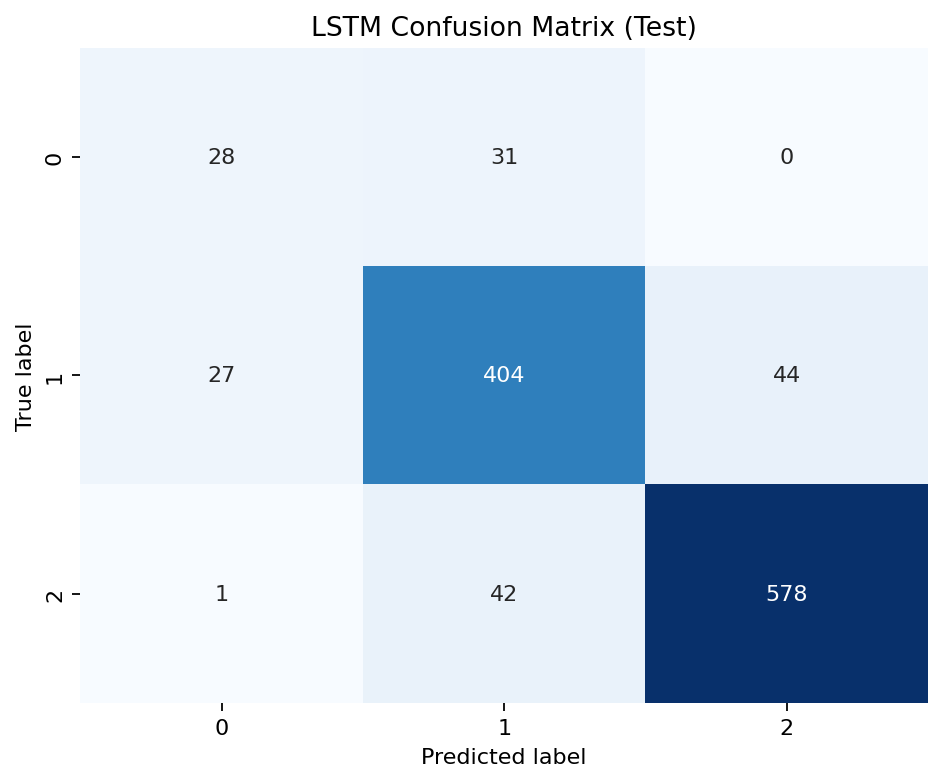

,0,1,2
0,28,31,0
1,27,404,44
2,1,42,578


Classification report (test set):
              precision    recall  f1-score   support

           0     0.5000    0.4746    0.4870        59
           1     0.8470    0.8505    0.8487       475
           2     0.9293    0.9308    0.9300       621

    accuracy                         0.8745      1155
   macro avg     0.7587    0.7520    0.7552      1155
weighted avg     0.8735    0.8745    0.8740      1155

Saved: /kaggle/working/credit_rating_artifacts/lstm_test_confusion_matrix.png
Saved: /kaggle/working/credit_rating_artifacts/lstm_test_confusion_matrix.csv
Saved: /kaggle/working/credit_rating_artifacts/lstm_test_classification_report.csv


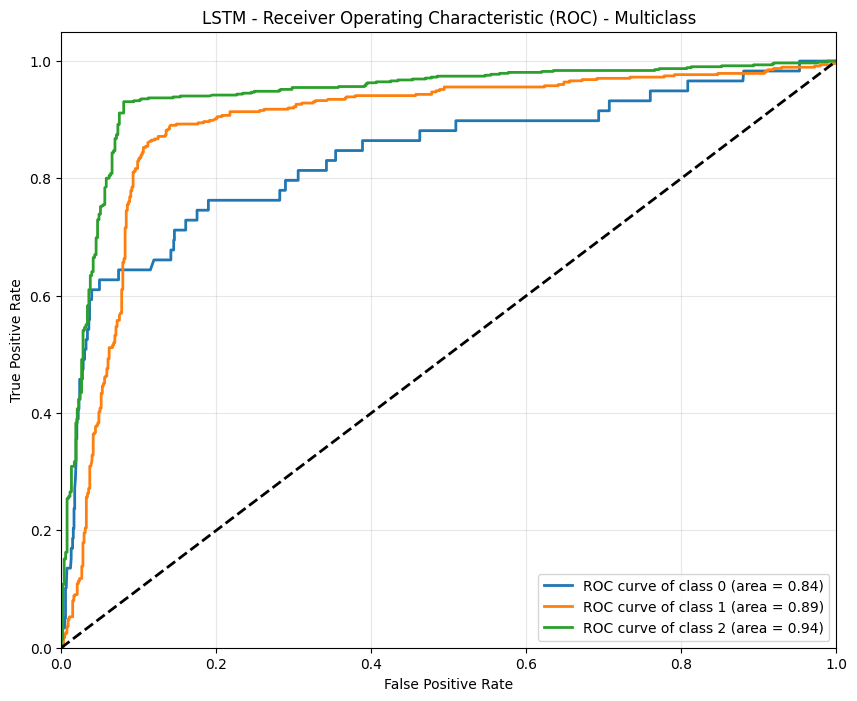

Saved: /kaggle/working/credit_rating_artifacts/lstm_test_roc_curves.png


In [5]:
if 'model' not in globals() or 'test_loader' not in globals():
    raise RuntimeError('Khong tim thay model/test_loader. Hay chay cell huan luyen truoc.')

from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_y_true, all_y_pred, all_logits = [], [], []

with torch.no_grad():
    for xb, lyb, sb, yb in test_loader:
        xb, lyb, sb = xb.to(device), lyb.to(device), sb.to(device)
        logits = model(xb, lyb, sb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_logits.append(logits.cpu())
        all_y_pred.append(preds)
        all_y_true.append(yb.numpy())

y_true = np.concatenate(all_y_true)
y_pred = np.concatenate(all_y_pred)
test_logits_all = torch.cat(all_logits)
test_proba = torch.softmax(test_logits_all, dim=1).numpy()

id_to_raw_local = {v: k for k, v in raw_to_id.items()} if 'raw_to_id' in globals() else {i: i for i in range(n_classes)}
class_labels = [str(id_to_raw_local.get(i, i)) for i in range(n_classes)]
label_ids = list(range(n_classes))

cm = confusion_matrix(y_true, y_pred, labels=label_ids)
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

plt.figure(figsize=(6, 5), dpi=160)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('LSTM Confusion Matrix (Test)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
cm_plot_path = ARTIFACT_DIR / 'lstm_test_confusion_matrix.png'
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
plt.show()

display(cm_df)
print('Classification report (test set):')
print(classification_report(
    y_true,
    y_pred,
    labels=label_ids,
    target_names=class_labels,
    digits=4,
    zero_division=0,
))

cls_report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=class_labels,
        output_dict=True,
        zero_division=0,
    )
).transpose()

cm_csv_path = ARTIFACT_DIR / 'lstm_test_confusion_matrix.csv'
cls_csv_path = ARTIFACT_DIR / 'lstm_test_classification_report.csv'
cm_df.to_csv(cm_csv_path, encoding='utf-8-sig')
cls_report_df.to_csv(cls_csv_path, encoding='utf-8-sig')

print('Saved:', cm_plot_path)
print('Saved:', cm_csv_path)
print('Saved:', cls_csv_path)

plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc_val:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM - Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
roc_plot_path = ARTIFACT_DIR / 'lstm_test_roc_curves.png'
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', roc_plot_path)

## Visualization: Training Curves

Biểu đồ train/validation theo chuẩn bài báo khoa học cho 5 metric: Loss, Accuracy, Macro F1, AUC, QWK.

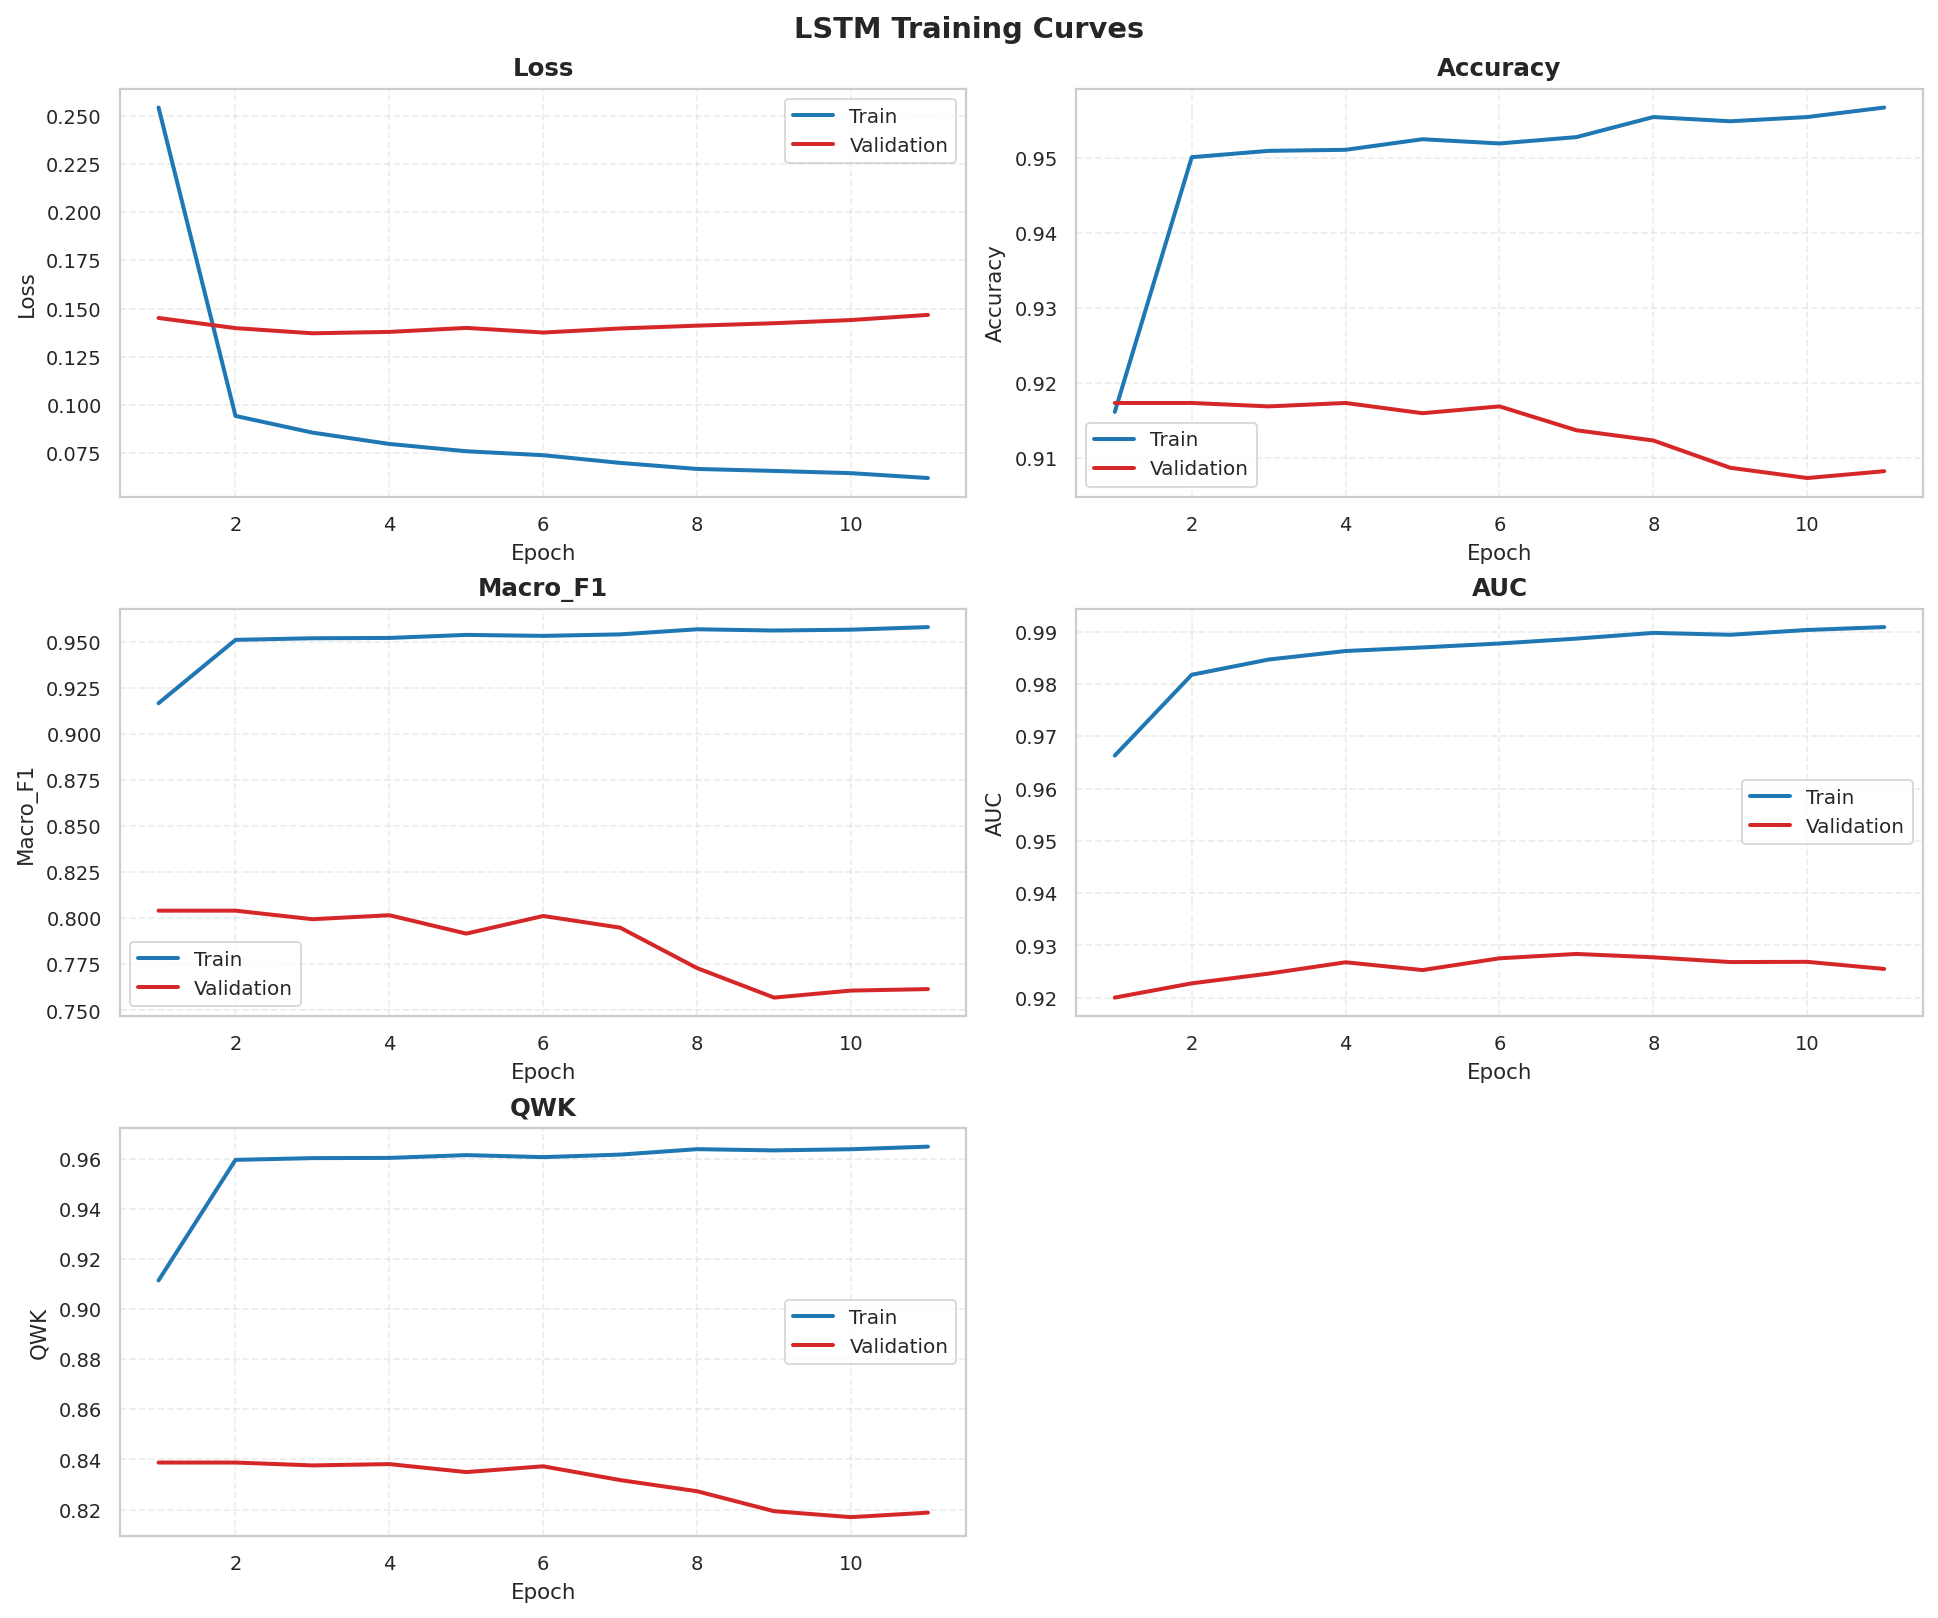

Saved: /kaggle/working/credit_rating_artifacts/lstm_training_curves.png


In [6]:
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

sns.set_theme(style='whitegrid', context='paper')
metrics = ['Loss', 'Accuracy', 'Macro_F1', 'AUC', 'QWK']
required_cols = [f'train_{m}' for m in metrics] + [f'val_{m}' for m in metrics]
missing = [c for c in required_cols if c not in history_df.columns]
if missing:
    raise RuntimeError(f'Thieu cot trong history_df: {missing}. Hay chay lai cell huan luyen.')

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=160, constrained_layout=True)
axes = axes.ravel()

for ax, metric in zip(axes, metrics):
    ax.plot(history_df['epoch'], history_df[f'train_{metric}'], label='Train', linewidth=1.8, color='#1f77b4')
    ax.plot(history_df['epoch'], history_df[f'val_{metric}'], label='Validation', linewidth=1.8, color='#d62728')
    ax.set_title(metric, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(frameon=True, fontsize=9)

for ax in axes[len(metrics):]:
    ax.axis('off')

fig.suptitle('LSTM Training Curves', fontsize=13, fontweight='bold')
curve_path = ARTIFACT_DIR / 'lstm_training_curves.png'
fig.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', curve_path)